In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import pandas as pd

In [16]:
data = [41.7, 36.7, 45.6, 31.0, 38.9, 28.3, 23.7, 54.5, 31.6, 26.1,
        50.4, 45.0, 53.5, 50.1, 29.7, 40.9, 32.4, 45.0, 35.6, 25.6,
        55.3, 33.1, 25.6, 40.2, 32.2, 43.2, 25.1, 29.9, 52.7, 18.6,
        35.3, 38.1, 29.4, 32.1, 43.0, 23.0, 34.1, 28.8, 31.6, 40.8,
        32.7, 43.0, 41.7, 41.7, 28.3, 23.1, 18.2, 23.5, 30.3, 36.2,
        34.9, 41.0, 54.3, 33.3, 39.3, 12.8, 20.6, 22.6, 26.1, 16.8]

data = np.array(data)
n = len(data)
print(f"Объем выборки n = {n}")
print(f"Минимум = {np.min(data):.2f}, Максимум = {np.max(data):.2f}")

Объем выборки n = 60
Минимум = 12.80, Максимум = 55.30


In [17]:
k = int(np.ceil(1 + 3.322 * np.log10(n)))
print(f"Число интервалов (Стерджесс): k = {k}")

# Построение интервалов
min_val = np.min(data)
max_val = np.max(data)
width = (max_val - min_val) / k
bins = [min_val + i * width for i in range(k + 1)]
bins[-1] = max_val  # фикс последней границы

# Частоты и середины интервалов
freq, _ = np.histogram(data, bins=bins)
rel_freq = freq / n
midpoints = [(bins[i] + bins[i+1]) / 2 for i in range(k)]

print("\nГруппировка данных:")
print("Интервал\t\tЧастота\tОтн. частота")
for i in range(k):
    print(f"[{bins[i]:.2f}; {bins[i+1]:.2f})\t{freq[i]}\t{rel_freq[i]:.4f}")


Число интервалов (Стерджесс): k = 7

Группировка данных:
Интервал		Частота	Отн. частота
[12.80; 18.87)	4	0.0667
[18.87; 24.94)	6	0.1000
[24.94; 31.01)	13	0.2167
[31.01; 37.09)	14	0.2333
[37.09; 43.16)	12	0.2000
[43.16; 49.23)	4	0.0667
[49.23; 55.30)	7	0.1167


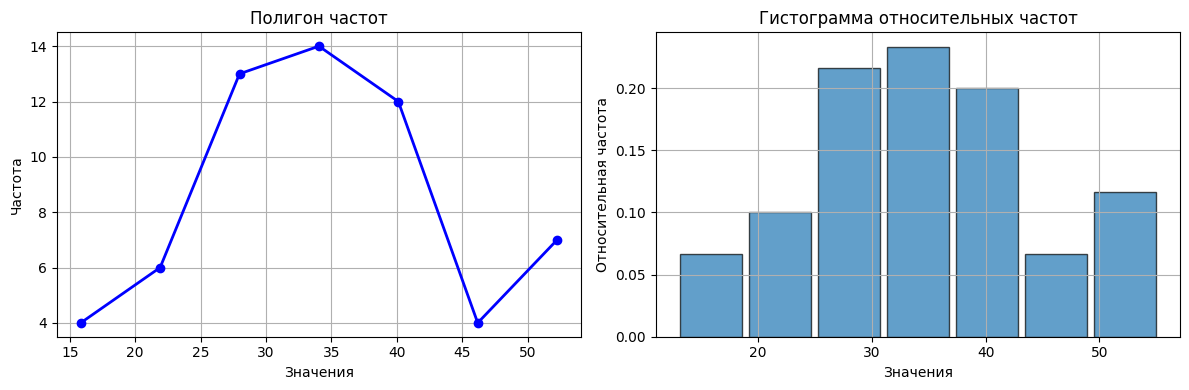

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Полигон частот
ax1.plot(midpoints, freq, 'bo-', linewidth=2, markersize=6)
ax1.set_title('Полигон частот')
ax1.set_xlabel('Значения')
ax1.set_ylabel('Частота')
ax1.grid(True)

# Гистограмма относительных частот
ax2.bar(midpoints, rel_freq, width=width*0.9, edgecolor='black', alpha=0.7)
ax2.set_title('Гистограмма относительных частот')
ax2.set_xlabel('Значения')
ax2.set_ylabel('Относительная частота')
ax2.grid(True)

plt.tight_layout()
plt.show()

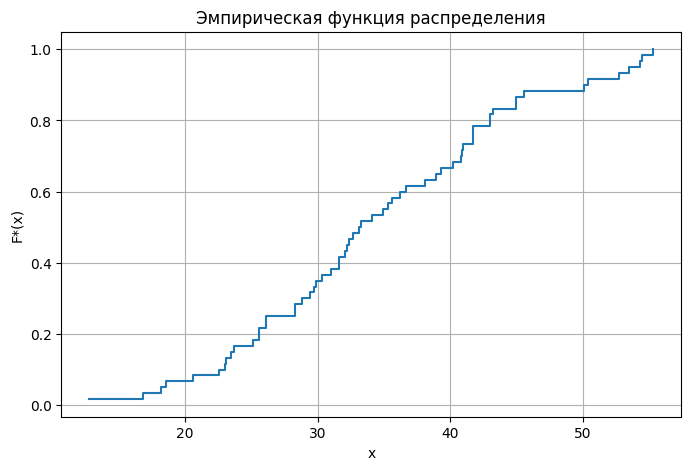


По виду гистограммы (колоколообразная форма) и эмпирической функции (S-образная)
выдвигаем гипотезу H0: генеральная совокупность распределена по нормальному закону.


In [19]:
sorted_data = np.sort(data)
ecdf_y = np.arange(1, n + 1) / n

plt.figure(figsize=(8, 5))
plt.step(sorted_data, ecdf_y, where='post', label='Эмпирическая ФР')
plt.title('Эмпирическая функция распределения')
plt.xlabel('x')
plt.ylabel('F*(x)')
plt.grid(True)
plt.show()

print("\nПо виду гистограммы (колоколообразная форма) и эмпирической функции (S-образная)")
print("выдвигаем гипотезу H0: генеральная совокупность распределена по нормальному закону.")

In [20]:
mu_hat = np.mean(data)
sigma_hat = np.std(data, ddof=1)  # несмещенная оценка
print(f"\nОценки параметров предполагаемого нормального распределения:")
print(f"Выборочное среднее (оценка мат. ожидания) = {mu_hat:.4f}")
print(f"Выборочное среднеквадратическое отклонение (несмещенное) = {sigma_hat:.4f}")


Оценки параметров предполагаемого нормального распределения:
Выборочное среднее (оценка мат. ожидания) = 34.6467
Выборочное среднеквадратическое отклонение (несмещенное) = 10.1893


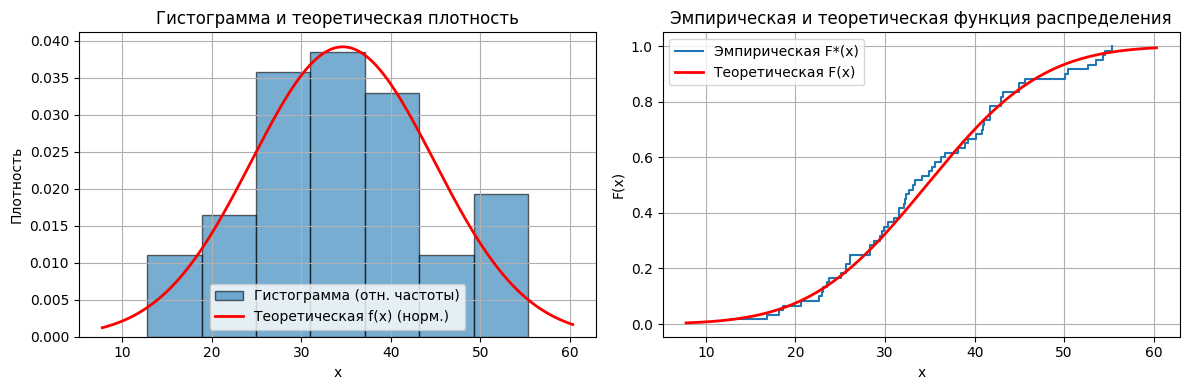

In [22]:
# 8. Построение гистограммы и эмпирической ФР с теоретическими аналогами
x_vals = np.linspace(min_val - 5, max_val + 5, 500)
pdf_theor = stats.norm.pdf(x_vals, mu_hat, sigma_hat)
cdf_theor = stats.norm.cdf(x_vals, mu_hat, sigma_hat)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Гистограмма + теоретическая плотность
ax1.hist(data, bins=bins, density=True, alpha=0.6, edgecolor='black', label='Гистограмма (отн. частоты)')
ax1.plot(x_vals, pdf_theor, 'r-', linewidth=2, label='Теоретическая f(x) (норм.)')
ax1.set_title('Гистограмма и теоретическая плотность')
ax1.set_xlabel('x')
ax1.set_ylabel('Плотность')
ax1.legend()
ax1.grid(True)

ax2.step(sorted_data, ecdf_y, where='post', label='Эмпирическая F*(x)')
ax2.plot(x_vals, cdf_theor, 'r-', linewidth=2, label='Теоретическая F(x)')
ax2.set_title('Эмпирическая и теоретическая функция распределения')
ax2.set_xlabel('x')
ax2.set_ylabel('F(x)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [23]:
# 9. Правило трех сигм
within_1sigma = np.sum(np.abs(data - mu_hat) <= sigma_hat) / n * 100
within_2sigma = np.sum(np.abs(data - mu_hat) <= 2 * sigma_hat) / n * 100
within_3sigma = np.sum(np.abs(data - mu_hat) <= 3 * sigma_hat) / n * 100

print(f"\nПравило трех сигм для выборки:")
print(f"В интервале x̅ ± σ: {within_1sigma:.2f}% (теор. ~68.27%)")
print(f"В интервале x̅ ± 2σ: {within_2sigma:.2f}% (теор. ~95.45%)")
print(f"В интервале x̅ ± 3σ: {within_3sigma:.2f}% (теор. ~99.73%)")

if np.abs(within_3sigma - 99.73) < 5:
    print("Правило трех сигм выполняется удовлетворительно.")
else:
    print("Правило трех сигм может не выполняться из-за малой выборки или отклонения от нормальности.")


Правило трех сигм для выборки:
В интервале x̅ ± σ: 66.67% (теор. ~68.27%)
В интервале x̅ ± 2σ: 96.67% (теор. ~95.45%)
В интервале x̅ ± 3σ: 100.00% (теор. ~99.73%)
Правило трех сигм выполняется удовлетворительно.


In [24]:
# 10. Критерий согласия Пирсона (хи-квадрат)
# Группируем так, чтобы ожидаемые частоты были не менее 5
freq_obs = freq
expected_prob = np.diff(stats.norm.cdf(bins, mu_hat, sigma_hat))
expected_freq = expected_prob * n

# Объединяем интервалы с малыми ожидаемыми частотами
new_bins = []
new_obs = []
new_exp = []
i = 0
while i < len(bins) - 1:
    cum_prob = 0
    cum_obs = 0
    cum_exp = 0
    j = i
    while j < len(bins) - 1 and (cum_exp < 5 or j == i):
        cum_obs += freq_obs[j]
        cum_exp += expected_freq[j]
        j += 1
    new_bins.append((bins[i], bins[j]))
    new_obs.append(cum_obs)
    new_exp.append(cum_exp)
    i = j

# Расчет хи-квадрат
chi2_stat = np.sum((np.array(new_obs) - np.array(new_exp)) ** 2 / np.array(new_exp))
df = len(new_obs) - 1 - 2  # число интервалов после объединения - 1 - число оцененных параметров
p_value = 1 - stats.chi2.cdf(chi2_stat, df)

print(f"\nКритерий согласия Пирсона (χ²):")
print(f"χ²_набл = {chi2_stat:.4f}")
print(f"Число степеней свободы = {df}")
print(f"p-value = {p_value:.4f}")

alpha = 0.05
critical = stats.chi2.ppf(1 - alpha, df)
print(f"Критическое значение (α=0.05): χ²_крит = {critical:.4f}")

if chi2_stat < critical:
    print("Гипотеза о нормальном распределении НЕ противоречит данным (принимаем H0).")
else:
    print("Гипотеза о нормальном распределении отвергается (H0 не принимается).")


Критерий согласия Пирсона (χ²):
χ²_набл = 6.1166
Число степеней свободы = 3
p-value = 0.1061
Критическое значение (α=0.05): χ²_крит = 7.8147
Гипотеза о нормальном распределении НЕ противоречит данным (принимаем H0).


In [25]:
# 11. Доверительные интервалы для генеральной средней и СКО при γ=0.95
gamma = 0.95
mean_sem = sigma_hat / np.sqrt(n)  # стандартная ошибка среднего
t_crit = stats.t.ppf((1 + gamma) / 2, df=n - 1)
ci_mean = (mu_hat - t_crit * mean_sem, mu_hat + t_crit * mean_sem)

# Доверительный интервал для дисперсии (и СКО) через хи-квадрат
chi2_low = stats.chi2.ppf((1 - gamma) / 2, df=n - 1)
chi2_high = stats.chi2.ppf((1 + gamma) / 2, df=n - 1)
ci_var = ((n - 1) * sigma_hat**2 / chi2_high, (n - 1) * sigma_hat**2 / chi2_low)
ci_std = (np.sqrt(ci_var[0]), np.sqrt(ci_var[1]))

print(f"\nДоверительные интервалы при γ = {gamma}:")
print(f"Для генеральной средней μ: [{ci_mean[0]:.4f}; {ci_mean[1]:.4f}]")
print(f"Для генерального СКО σ:  [{ci_std[0]:.4f}; {ci_std[1]:.4f}]")


Доверительные интервалы при γ = 0.95:
Для генеральной средней μ: [32.0145; 37.2788]
Для генерального СКО σ:  [8.6368; 12.4275]
